In [2]:

%pip install pyreadstat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 꺠짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [30]:
from matplotlib import font_manager

fonts = [f.name for f in font_manager.fontManager.ttflist]
print(sorted(set(fonts)))

['Agency FB', 'Algerian', 'Ami R', 'Arial', 'Arial Black', 'Arial Narrow', 'Arial Rounded MT Bold', 'Bahnschrift', 'Baskerville Old Face', 'Batang', 'BatangChe', 'Bauhaus 93', 'Bell MT', 'Berlin Sans FB', 'Berlin Sans FB Demi', 'Bernard MT Condensed', 'Blackadder ITC', 'Bodoni MT', 'Bodoni MT Black', 'Bodoni MT Condensed', 'Bodoni MT Poster Compressed', 'Book Antiqua', 'Bookman Old Style', 'Bookshelf Symbol 7', 'Bradley Hand ITC', 'Britannic Bold', 'Broadway', 'Brush Script MT', 'Calibri', 'Calibri Light', 'Californian FB', 'Calisto MT', 'Cambria', 'Cambria Math', 'Candara', 'Candara Light', 'Cascadia Code', 'Cascadia Mono', 'Castellar', 'Centaur', 'Century', 'Century Gothic', 'Century Schoolbook', 'Chiller', 'Colonna MT', 'Comic Sans MS', 'Consolas', 'Constantia', 'Cooper Black', 'Copperplate Gothic Bold', 'Copperplate Gothic Light', 'Corbel', 'Corbel Light', 'Courier New', 'Curlz MT', 'DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif Display', 'D

In [31]:
df = pd.read_spss('data/Koweps_hpwc20_2025_beta1.sav')
# 상위 5개 확인
df.head()
# 하위 5개 확인
df.tail()

,h20_id,h20_ind,h20_sn,h20_merkey,h_new,h_new1,h20_cobf,p20_wsc,p20_wsl,p20_wgc,...,wc20_63,wc20_64,wc20_5aq4,wc20_5aq5,wc20_5aq6,h20_pers_income1,h20_pers_income2,h20_pers_income3,h20_pers_income4,h20_pers_income5
14910,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,12820.0,NaN,NaN,0.0,NaN
14911,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3149.0,NaN,0.0,NaN
14912,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
14913,12011.0,17.0,1.0,120111701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,6600.0,NaN,0.0,NaN
14914,12011.0,17.0,1.0,120111701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN


In [ ]:
# 원본 데이터 보존용 백업
raw_data = df.copy()

In [ ]:
df.info()   # 데이터 전체 구조 파악

<class 'pandas.DataFrame'>
RangeIndex: 14915 entries, 0 to 14914
Columns: 834 entries, h20_id to h20_pers_income5
dtypes: float64(833), str(1)
memory usage: 94.9 MB


In [4]:
df.columns  # 데이터프레임 모든 변수명 출력

NameError: name 'df' is not defined

In [5]:
df.describe()   # 수치형 변수들의 통계 요약

NameError: name 'df' is not defined

In [ ]:
h20_g3 # 성별
h20_g4 # 출생연도

h20_eco9 # 직종
p2002_8aq1 # 월급




NameError: name 'h20_g3' is not defined

In [32]:
# 사용할 컬럼 이름 변경
data = df.rename(columns={
    "h20_g3" : 'sex',
    "h20_g4" : 'birth',
    'h20_eco9' : "job_code",
    'p2002_8aq1' : 'income'
})

# 필요한 컬럼만 
data = data[['sex','birth','job_code','income']]

In [33]:
# 기초 통계자료 확인
data.describe()

,sex,birth,job_code,income
count,14915.000000,14915.000000,7827.000000,5423.000000
mean,1.551190,1970.486490,590.347898,304.979532
std,0.497389,24.162482,270.515224,239.802030
min,1.000000,1917.000000,111.000000,0.000000
25%,1.000000,1950.000000,313.000000,134.500000
50%,2.000000,1967.000000,611.000000,263.000000
75%,2.000000,1989.000000,873.000000,402.500000
max,2.000000,2024.000000,1009.000000,2208.000000


In [34]:
# 값이 고유한지 확인 , 1 = 남성, 2 = 여성
data['sex'].unique()

array([2., 1.])

In [35]:
# 결측치 개수 확인(=isna().sum())
data['sex'].isnull().sum()

np.int64(0)

In [36]:
# 값별 빈도수 확인
data['sex'].value_counts()

sex
2.0    8221
1.0    6694
Name: count, dtype: int64

### np.where(조건, 값1, 값2) : 조건이 참일떄 값1, 거짓이면 값2

In [37]:
# 성별 컬럼이 1.0 이면 'M', 아니면 'F'
data['sex'] = np.where(data['sex'] == 1.0, 'M', 'F')

data.head()

,sex,birth,job_code,income
0,F,1945.0,NaN,NaN
1,M,1948.0,942.0,200.0
2,M,1942.0,NaN,NaN
3,M,1962.0,855.0,235.0
4,F,1963.0,314.0,190.0


<Axes: xlabel='sex', ylabel='count'>

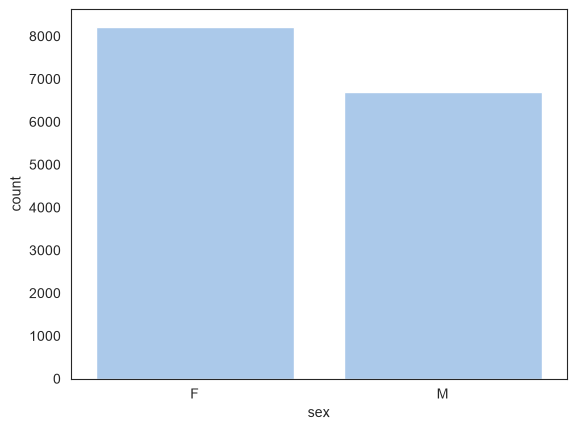

In [38]:
# 시각화 스타일 설정 : 배경 흰색, 파스텔 톤
sns.set_style('white')
sns.set_palette('pastel')

sns.countplot(x= 'sex', data= data)

In [39]:
data

,sex,birth,job_code,income
0,F,1945.0,NaN,NaN
1,M,1948.0,942.0,200.0
2,M,1942.0,NaN,NaN
3,M,1962.0,855.0,235.0
4,F,1963.0,314.0,190.0
...,...,...,...,...
14910,M,1975.0,222.0,1010.0
14911,F,1976.0,313.0,260.0
14912,F,2009.0,NaN,NaN
14913,M,1964.0,151.0,550.0


<Axes: xlabel='income', ylabel='Count'>

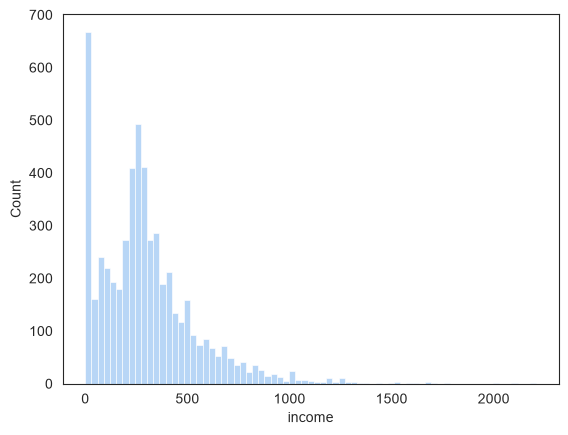

In [40]:
# 수입 분포 확인
sns.histplot(data['income'])

In [41]:
data['income'].isnull().sum()

np.int64(9492)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'income'),
  Text(1, 0, 'job_code'),
  Text(2, 0, 'birth'),
  Text(3, 0, 'sex')])

c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) Arial.
  func(*args,

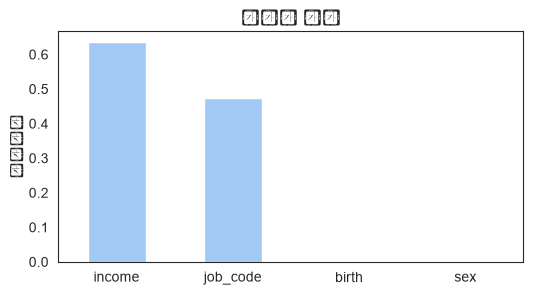

In [42]:
na_rate = data.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(6,3))
na_rate.plot(kind = 'bar')
plt.title('결측치 비율')
plt.ylabel('결측비율')
plt.xticks(rotation=0)


In [43]:
data

,sex,birth,job_code,income
0,F,1945.0,NaN,NaN
1,M,1948.0,942.0,200.0
2,M,1942.0,NaN,NaN
3,M,1962.0,855.0,235.0
4,F,1963.0,314.0,190.0
...,...,...,...,...
14910,M,1975.0,222.0,1010.0
14911,F,1976.0,313.0,260.0
14912,F,2009.0,NaN,NaN
14913,M,1964.0,151.0,550.0


Text(0.5, 1.0, '성별 별 소득 결측치')

c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 46301 (\N{HANGUL SYLLABLE DEUG}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) Arial.
  func(*

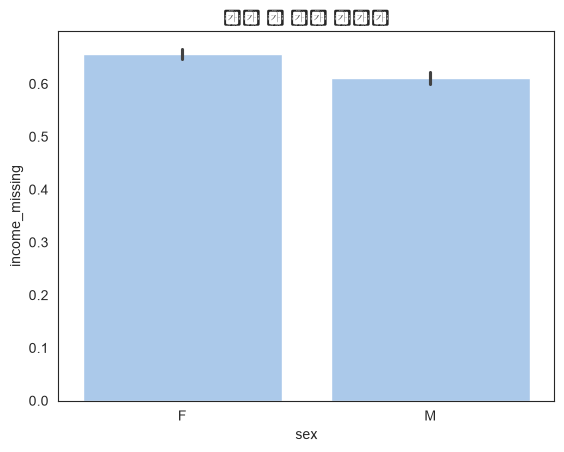

In [44]:
# assign(): 기존 데이터프레임에 새로운 파생변수 추가
tmp = data.assign(income_missing= data['income'].isna())
sns.barplot(x='sex', y='income_missing',data= tmp)
plt.title("성별 별 소득 결측치")

In [45]:
# income 결측치 제거
sex_income = data.dropna(subset=['income'])
sex_income.isnull().sum()

sex         0
birth       0
job_code    0
income      0
dtype: int64

In [46]:
# 성별로 그룹화 시키고 평균소득 계산
sex_income = sex_income.groupby('sex')['income'].mean()
sex_income

sex
F    216.944681
M    400.353438
Name: income, dtype: float64

<Axes: xlabel='sex'>

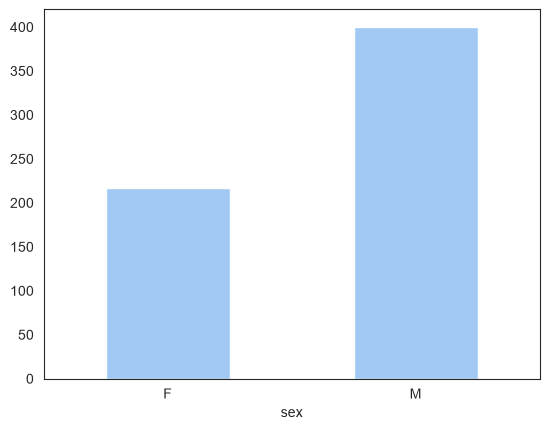

In [47]:
# plot.bar() : pandas 의 Series 나 Groupby 결과를 막대그래프로 바로출력
sex_income.plot.bar(rot=0)

c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  fi

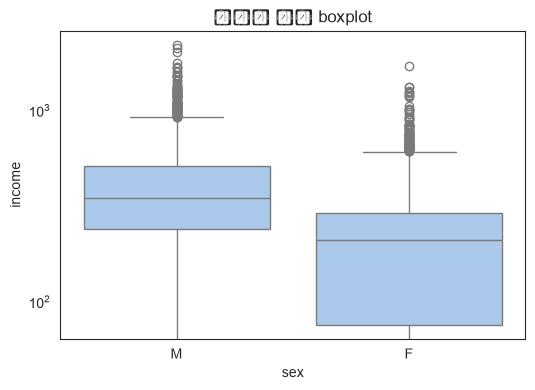

In [48]:
tmp = data.dropna(subset=['income'])
plt.figure(figsize= (6,4))
sns.boxplot(x='sex',y='income',data=tmp)
plt.title('성별별 임금 boxplot')
plt.yscale('log')    # Y 값에 log 스케일 적용

In [49]:
# 남성 소득이 여성 소득에 비해 몇 배 높은지 확인



ttest_ind() : 통계적 유의성 검정하는 함수  
equal_var = True : 두 집단이 등분산을 가정

In [50]:
import scipy.stats as stats

sex_m = data[data['sex']== 'M'].dropna()
sex_f = data[data['sex']== 'F'].dropna()

# 두 데이터를 등분산 가정후 t-test
stats.ttest_ind(sex_m['income'], sex_f['income'], equal_var=True)

TtestResult(statistic=np.float64(30.447322061310594), pvalue=np.float64(4.1662077102696945e-188), df=np.float64(5421.0))

t-test 결과 해석  
statistic (t - 값) : 값이 크면 두 집단의 평균 차이가 크다.  
pvalue : 0 에 거의 근접 -> pvalue 기준인 0.05 작다 -> 귀무가설 기각  
남성과 여성의 평균 소득에는 유의미한 차이가 있다.  

In [51]:
data['birth'].describe()

count    14915.000000
mean      1970.486490
std         24.162482
min       1917.000000
25%       1950.000000
50%       1967.000000
75%       1989.000000
max       2024.000000
Name: birth, dtype: float64

In [52]:
# age 컬럼 = 2026 - 출생연도
data['age'] = 2026 - data["birth"] 
data


,sex,birth,job_code,income,age
0,F,1945.0,NaN,NaN,81.0
1,M,1948.0,942.0,200.0,78.0
2,M,1942.0,NaN,NaN,84.0
3,M,1962.0,855.0,235.0,64.0
4,F,1963.0,314.0,190.0,63.0
...,...,...,...,...,...
14910,M,1975.0,222.0,1010.0,51.0
14911,F,1976.0,313.0,260.0,50.0
14912,F,2009.0,NaN,NaN,17.0
14913,M,1964.0,151.0,550.0,62.0


In [54]:
# age 컬럼을 정수형으로 변환
data['age'] = data['age'].astype(int)
data['age'].dtype
data[['h20_pid','age']].head()

KeyError: "['h20_pid'] not in index"

<Axes: xlabel='age'>

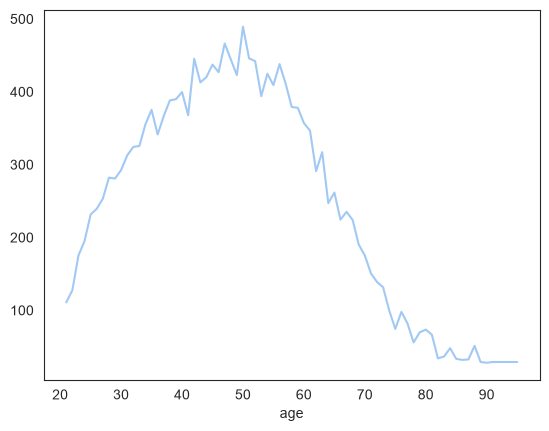

In [57]:
# 소득 결측치 제거
data_income = data.dropna(subset=['income'])


# 나이별 평균 소득 계산
data_income = data_income.groupby('age')['income'].mean()
data_income

#선그래프 시각화 plot(): Series 형태로 선그래프를 시각화
data_income.plot()

In [58]:
print(data_income.max())        # 가장 높은 평균소득
print(data_income.idxmax())     # 가장 평균소득이 높은 나이

489.1926605504587
50


In [61]:
# 나이별로 평균소득 내림차순 정렬
data_income.sort_values(ascending=False)

age
50    489.192661
47    466.240741
51    445.901639
42    445.314286
48    444.464286
         ...    
92     29.000000
94     29.000000
93     29.000000
95     29.000000
90     27.923077
Name: income, Length: 75, dtype: float64

In [65]:
# 파생변수 컬럼 만들기

# 30세 미만 청년층, 30세 이상 60세 미만 중장년층, 60세 이상은 고령층
data = data.assign(
    agetype = np.where(
        data['age'] < 30, 'youth',  
        np.where(       # np.where 안에 또 np.where -> elif
            data['age'] <60 , 'middle_age', 'senior'
        )
    )
)

data

,sex,birth,job_code,income,age,agetype
0,F,1945.0,NaN,NaN,81,senior
1,M,1948.0,942.0,200.0,78,senior
2,M,1942.0,NaN,NaN,84,senior
3,M,1962.0,855.0,235.0,64,senior
4,F,1963.0,314.0,190.0,63,senior
...,...,...,...,...,...,...
14910,M,1975.0,222.0,1010.0,51,middle_age
14911,F,1976.0,313.0,260.0,50,middle_age
14912,F,2009.0,NaN,NaN,17,youth
14913,M,1964.0,151.0,550.0,62,senior


<Axes: xlabel='agetype', ylabel='count'>

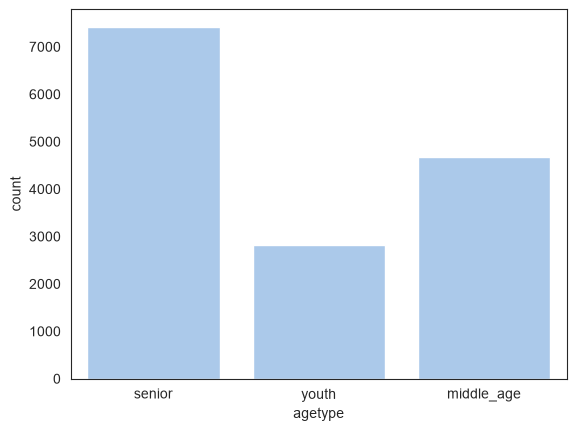

In [66]:
# 연령대별 응답자 수 막대 그래프
sns.countplot(x='agetype',data=data)

<Axes: xlabel='agetype'>

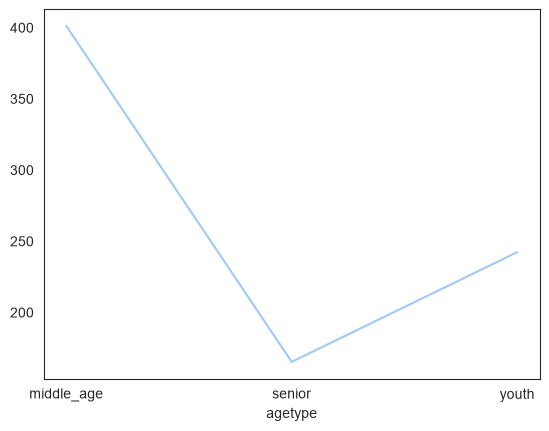

In [68]:
# 연령대 별 평균 소득 계산

agetype_income = data.groupby('agetype')['income'].mean()
agetype_income.plot()

In [82]:
# (연령대, 성별) 조합으로 그룹화하고 평균 소득 계산
data.groupby(['sex', 'agetype'])['income'].mean()


sex  agetype   
F    middle_age    302.627606
     senior        111.916667
     youth         228.520755
M    middle_age    483.292639
     senior        249.140351
     youth         261.387435
Name: income, dtype: float64

In [89]:
# 소득 결측치 제거 후, (성별과 나이)로 그룹화하고 평균소득 계산
# as_index = False : 그룹화한 컬럼을 인덱스로 쓰지않음
age_sex_income = data.dropna(subset=['income']).groupby(
    ['sex','age'],as_index=False    
    )['income'].mean()

age_sex_income


,sex,age,income
0,F,21,86.375000
1,F,22,110.916667
2,F,23,156.200000
3,F,24,178.125000
4,F,25,228.900000
...,...,...,...
143,M,90,29.000000
144,M,91,29.000000
145,M,93,29.000000
146,M,94,29.000000


<Axes: xlabel='age', ylabel='income'>

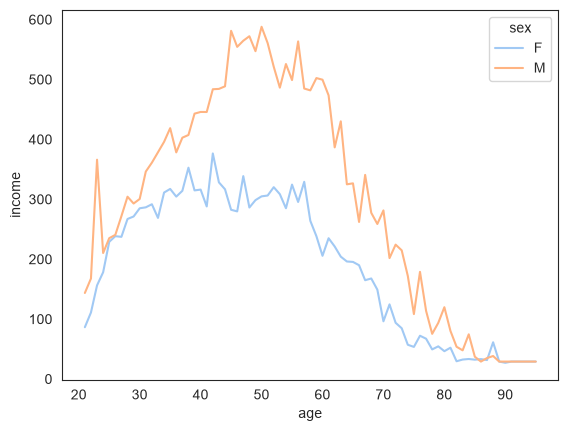

In [91]:
sns.lineplot(x='age', y= 'income', data= age_sex_income, hue= 'sex')

In [97]:
# 남성/여성 소득 비율 그래프
# unstack() : 인덱스에 있던 값을 컬럼으로 펼쳐준다.
age_mean = data.dropna(subset=['income']).groupby(['age','sex'])['income'].mean().unstack()

# 여성평균소득대비 남성평균소득 비율
age_mean['ratio_M_over_F'] = age_mean['M'] / age_mean["F"]
age_mean


sex,F,M,ratio_M_over_F
age,,,
21,86.375000,143.500000,1.661360
22,110.916667,167.600000,1.511044
23,156.200000,366.000000,2.343150
24,178.125000,210.222222,1.180195
25,228.900000,235.000000,1.026649
...,...,...,...
91,29.000000,29.000000,1.000000
92,29.000000,NaN,NaN
93,29.000000,29.000000,1.000000


Text(0, 0.5, 'M/F')

c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\MoonSungHo\skn34-st\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) Arial.
  func(*

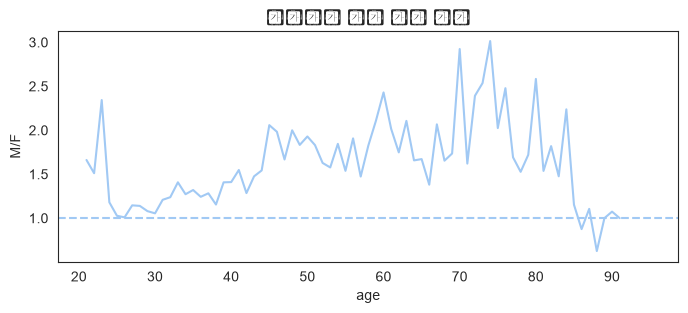

In [98]:
# 연령대별 남여 평균소득 시각화

age_mean['ratio_M_over_F'].plot(figsize=(8,3))
plt.axhline(1, linestyle= '--')     # 
plt.title('연령대별 남여 소득 비율')
plt.ylabel('M/F')

In [108]:
len(data['job_code'].unique()) # 직종코드 고유값 수

154

In [111]:
sheet_name = '직종코드 (2019 7차 신분류)'

job_name = pd.read_excel(
    'data/(2025년 20차 한국복지패널조사) 조사설계서-가구용(beta1).xlsx',
    sheet_name = '직종코드(2019 7차 신분류)')

In [112]:
job_name

,대분류,중분류,소분류,Unnamed: 3,직종코드는 소분류의 네자리를 넣음
0,1. 관리자,11. 공공 기관 및 기업 고위직,111,의회 의원∙고위 공무원 및 공공단체 임원,NaN
1,NaN,NaN,112,기업 고위 임원,NaN
2,NaN,12. 행정∙경영 지원 및 마케팅 관리직,121,행정 및 경영 지원 관리자,NaN
3,NaN,NaN,122,마케팅 및 광고∙홍보 관리자,NaN
4,NaN,13. 전문 서비스 관리직,131,연구∙교육 및 법률 관련 관리자,NaN
...,...,...,...,...,...
151,NaN,NaN,992,계기∙자판기 및 주차 관리 종사자,NaN
152,NaN,NaN,999,기타 서비스 관련 단순 종사자,NaN
153,A. 군인,A0. 군인,1001,장교,NaN
154,NaN,NaN,1002,부사관,NaN


In [124]:
# 소분류, Unnamed: 3
# job_code, job 으로 각각 변경

job_name.rename(columns= {
    '소분류' : 'job_code',
    'Unnamed: 3' : 'job'
},inplace=True)

KeyError: "['job_name'] not in index"

In [139]:
job_name = job_name[['job_code','job']]

job_name

,job_code,job
0,111,의회 의원∙고위 공무원 및 공공단체 임원
1,112,기업 고위 임원
2,121,행정 및 경영 지원 관리자
3,122,마케팅 및 광고∙홍보 관리자
4,131,연구∙교육 및 법률 관련 관리자
...,...,...
151,992,계기∙자판기 및 주차 관리 종사자
152,999,기타 서비스 관련 단순 종사자
153,1001,장교
154,1002,부사관


In [142]:
# data(분석데이터)와 job_name(직업별 매핑표)을 job_code 기준으로 매핑하여 결합
# job_code 기준으로 left join
job_df = data.merge(job_name, how= 'left', on= 'job_code')
job_df


,sex,birth,job_code,income,age,agetype,job
0,F,1945.0,NaN,NaN,81,senior,NaN
1,M,1948.0,942.0,200.0,78,senior,건물 관리원 및 검표원
2,M,1942.0,NaN,NaN,84,senior,NaN
3,M,1962.0,855.0,235.0,64,senior,금속기계 부품 조립원
4,F,1963.0,314.0,190.0,63,senior,비서 및 사무 보조원
...,...,...,...,...,...,...,...
14910,M,1975.0,222.0,1010.0,51,middle_age,컴퓨터 시스템 및 소프트웨어 전문가
14911,F,1976.0,313.0,260.0,50,middle_age,회계 및 경리 사무원
14912,F,2009.0,NaN,NaN,17,youth,NaN
14913,M,1964.0,151.0,550.0,62,senior,판매 및 운송 관리자


In [153]:
# 직업별 평균소득 계산
# 직업명과 소득이 모두 존재하는 행만 필터링

job_income_mean = job_df.dropna(subset=['income','job'])
job_income_mean
# 직업명을 기준으로 그룹화 하여 평균 소득 계산
job_income_mean = job_income_mean.groupby('job')['income'].mean()
job_income_mean


job
가사 및 육아 도우미                103.472727
간호사                        363.651515
감정∙기술영업및중개관련종사자            563.833333
건물 관리원 및 검표원               239.902778
건설 및 광업 단순 종사자             298.431034
                              ...    
화학∙고무 및 플라스틱 제품 생산기 조작원    550.928571
화학공학 기술자 및 시험원             717.000000
환경∙청소 및 경비 관련 관리자          193.928571
환경공학∙가스·에너지 기술자 및 시험원      378.750000
회계 및 경리 사무원                357.033473
Name: income, Length: 152, dtype: float64

In [159]:
# 직업별 평균소득을 내림차순으로 정렬하고 상위 10개만 출력
job_income_mean.sort_values(ascending=False).head(10)  

job
의료 진료 전문가              1143.800000
인사 및 경영 전문가             975.250000
컴퓨터 하드웨어 및 통신공학 전문가     796.300000
기업 고위 임원                795.428571
기계∙로봇공학 기술자 및 시험원       750.750000
장교                      743.250000
화학공학 기술자 및 시험원          717.000000
보험 및 금융 관리자             715.571429
법률 전문가                  702.800000
행정 전문가                  691.000000
Name: income, dtype: float64

In [165]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트
mpl.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지

Text(0.5, 1.0, '상위 10개 직업 평균 소득 랭킹')

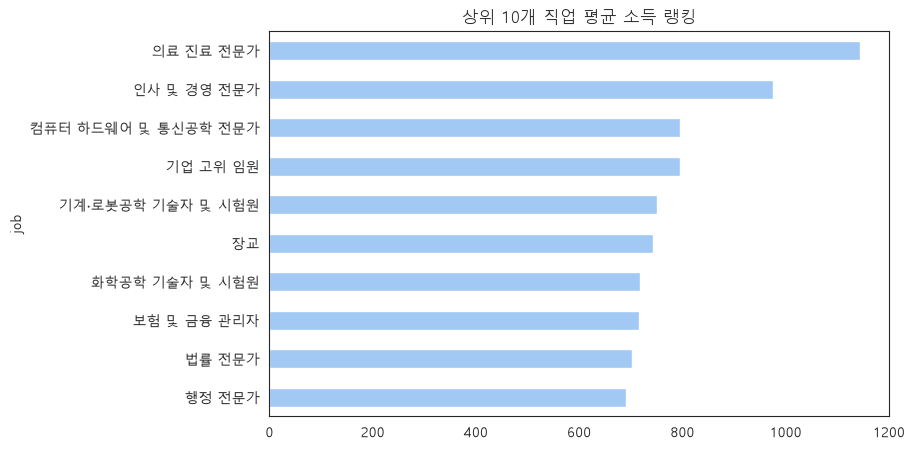

In [166]:
top10 = job_income_mean.sort_values(ascending=False).head(10).sort_values()

plt.figure(figsize=(8,5))
top10.plot(kind='barh')
plt.title('상위 10개 직업 평균 소득 랭킹')


Text(0.5, 1.0, '하위 10개 직업 평균 소득 랭킹')

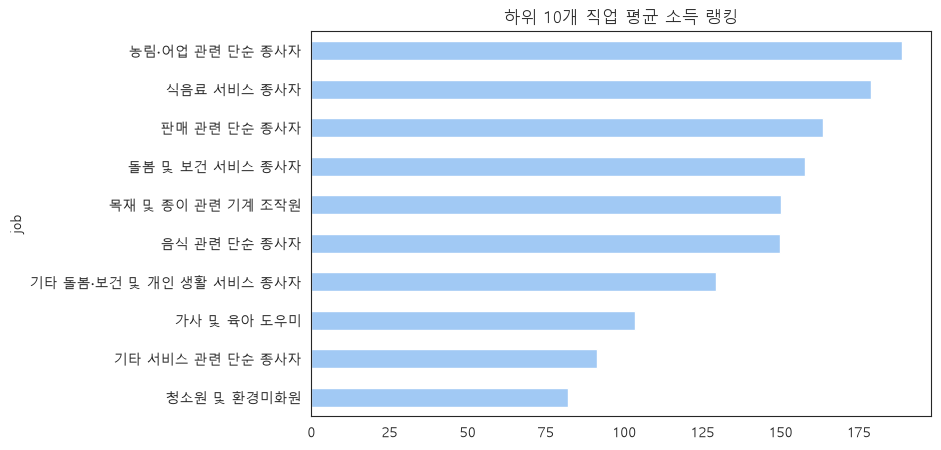

In [172]:
low10 = job_income_mean.sort_values().head(10)

plt.figure(figsize=(8,5))
low10.plot(kind='barh')
plt.title('하위 10개 직업 평균 소득 랭킹')


In [ ]:
job_income_mean.sort_values(ascending=False).head(10) 